# F01 – Publication Figures

High-quality figures for the paper.

## 0 – Imports & config

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pyvista as pv


def find_project_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        for candidate in (base, base / 'lv-scar-segmentation'):
            if (candidate / 'src' / 'data_loading.py').exists():
                return candidate.resolve()
    raise FileNotFoundError('Could not locate lv-scar-segmentation.')


ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data_loading import scan
from src.mesh_utils import best_shell, best_rv_mesh, get_cz_mesh
from src.plot_style import set_tfg_style, save_figure

HD_ROOT = r'F:/RM_TEKNON_DEVELOP'
RESULTS = ROOT / 'results'
OUT = RESULTS / 'F01_figures'
OUT.mkdir(parents=True, exist_ok=True)

# Set to None to auto-select best candidate, or e.g. '2023/12345678'
OVERRIDE_CASE = None

pv.set_jupyter_backend('static')
set_tfg_style()

print(f'Project root: {ROOT}')
print(f'Output dir  : {OUT}')

Project root: C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\lv-scar-segmentation
Output dir  : C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\lv-scar-segmentation\results\F01_figures


## 1 – Scan & select representative case

Find cases with Core Zone + Border Zone + Corridors + RV.  
Score by scar completeness (more components = higher rank).

In [37]:
def _exists(path):
    return path is not None and Path(str(path)).exists() and Path(str(path)).stat().st_size > 0


def _mesh_area_cm2(path):
    """Surface area cm² as proxy for tissue mass (mm² → cm²)."""
    if not _exists(path):
        return 0.0
    try:
        return pv.read(str(path)).area / 100.0
    except Exception:
        return 0.0


def _count_corridors(path):
    """Count distinct corridor IDs from a Corridor Labels VTK (positive labels)."""
    if not _exists(path):
        return 0
    try:
        m = pv.read(str(path))
        for arrays in (m.cell_data, m.point_data):
            for name in arrays.keys():
                arr = np.asarray(arrays[name]).ravel().astype(float)
                ids = np.unique(arr[np.isfinite(arr)].astype(int))
                ids = ids[ids > 0]
                if len(ids) > 0:
                    return int(len(ids))
    except Exception:
        pass
    return 0


all_cases = scan(HD_ROOT)

scored = []
for c in all_cases:
    ts = c.tissue_surfaces
    if best_shell(c) is None or not _exists(ts.get('core')):
        continue
    cz_area = _mesh_area_cm2(ts.get('core'))
    bz_area = _mesh_area_cm2(ts.get('border_zone'))
    n_corr  = _count_corridors(ts.get('corridor_labels'))
    # weighted: BZ and corridors are required for a complete figure
    score = cz_area * 0.4 + bz_area * 0.4 + n_corr * 2.0
    scored.append((score, cz_area, bz_area, n_corr, c))

scored.sort(key=lambda x: x[0], reverse=True)

print('Top-10 candidates  (score = 0.4*CZ_cm² + 0.4*BZ_cm² + 2*n_corridors)')
print(f'  {"score":>6}  {"CZ cm²":>7}  {"BZ cm²":>7}  {"#corr":>5}  patient')
for score, cz, bz, nc, c in scored[:10]:
    print(f'  {score:6.1f}  {cz:7.1f}  {bz:7.1f}  {nc:5d}  {c.year}/{c.patient_id}')

Top-10 candidates  (score = 0.4*CZ_cm² + 0.4*BZ_cm² + 2*n_corridors)
   score   CZ cm²   BZ cm²  #corr  patient
   254.1     70.8    254.4     62  2022/50038444
   234.9     70.5    266.8     50  2024/09005228
   189.9     48.0    291.7     27  2022/19036596
   184.6     45.5    331.0     17  2021/03005263
   181.7     82.7    371.5      0  2023/13035730
   152.5     13.2    368.0      0  2023/50009828
   146.2     46.4    319.1      0  2023/20047765
   146.0     38.1    327.0      0  2023/50066256
   144.5     17.8    298.3      9  2024/50101773
   137.0     40.0    302.4      0  2024/50122488


In [38]:
if OVERRIDE_CASE is not None:
    key_map = {f'{c.year}/{c.patient_id}': c for c in all_cases}
    rep = key_map[OVERRIDE_CASE]
else:
    _, _cz, _bz, _nc, rep = scored[0]

print(f'Selected: {rep.year}/{rep.patient_id}')

ts = rep.tissue_surfaces
lv_shell   = best_shell(rep)
rv_mesh    = best_rv_mesh(rep)
cz_mesh    = pv.read(str(ts['core']))                           if _exists(ts.get('core'))                           else None
bz_mesh    = pv.read(str(ts['border_zone']))                   if _exists(ts.get('border_zone'))                   else None
corr_mesh  = pv.read(str(ts['corridors']))                     if _exists(ts.get('corridors'))                     else None
# centerlines used for tube rendering (thicker corridors)
cl_mesh    = pv.read(str(ts['corridor_centerlines_unified']))  if _exists(ts.get('corridor_centerlines_unified'))  else None

for name, m in [('LV shell', lv_shell), ('RV', rv_mesh),
                ('Core Zone', cz_mesh), ('Border Zone', bz_mesh),
                ('Corridors (surf)', corr_mesh), ('Centerlines', cl_mesh)]:
    status = f'{m.n_points:,} pts' if m is not None else 'NOT FOUND'
    print(f'  {name:<18}: {status}')

# auto-estimate tube radius from corridor mesh bounds (≈3% of LV diagonal)
if corr_mesh is not None and lv_shell is not None:
    diag = np.linalg.norm(np.array(lv_shell.bounds[1::2]) - np.array(lv_shell.bounds[::2]))
    TUBE_RADIUS = max(1.5, diag * 0.025)
else:
    TUBE_RADIUS = 2.5
print(f'  Tube radius: {TUBE_RADIUS:.2f} mm')

Selected: 2022/50038444
  LV shell          : 10,702 pts
  RV                : 3,478 pts
  Core Zone         : 3,354 pts
  Border Zone       : 11,030 pts
  Corridors (surf)  : 4,990 pts
  Centerlines       : 855 pts
  Tube radius: 4.16 mm


## Fig 1 - Representative LV shell

Single isometric view: semi-transparent LV myocardium + Core Zone (red).

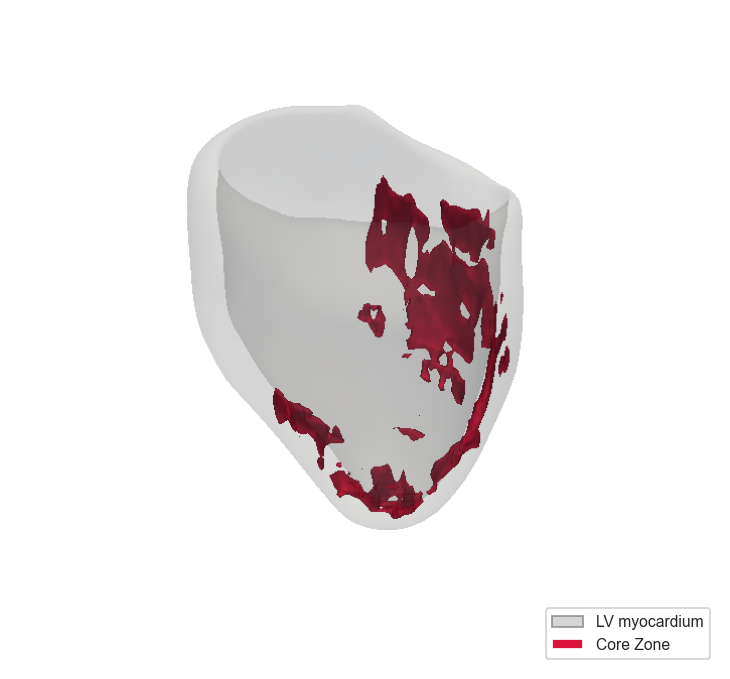

Saved: C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\lv-scar-segmentation\results\F01_figures\fig1_representative_lv.png


In [39]:
# -- colour palette (shared with all figures) ---------------------------
C_SHELL  = '#cccccc'
C_RV     = '#b0c4de'
C_CZ     = 'crimson'
C_BZ     = '#2980b9'
C_CORR   = '#f1c40f'
OP_SHELL = 0.15
OP_RV    = 0.10
OP_CZ    = 0.95
OP_BZ    = 0.45
OP_CORR  = 0.95
WIN_W, WIN_H = 700, 650


def _add_corridors(pl):
    if corr_mesh is not None:
        pl.add_mesh(corr_mesh, color=C_CORR, opacity=OP_CORR,
                    smooth_shading=True, show_scalar_bar=False)
        return
    if cl_mesh is not None:
        try:
            tubes = cl_mesh.tube(radius=TUBE_RADIUS, n_sides=12)
            pl.add_mesh(tubes, color=C_CORR, opacity=OP_CORR,
                        smooth_shading=True, show_scalar_bar=False)
        except Exception:
            pass


# -- Fig 1: simple LV shell + CZ, single isometric view -----------------
# lv_shell and cz_mesh loaded in cell 5
pl = pv.Plotter(off_screen=True, window_size=(WIN_W, WIN_H))
pl.set_background('white')
if lv_shell is not None:
    pl.add_mesh(lv_shell, color=C_SHELL, opacity=OP_SHELL,
                smooth_shading=True, show_scalar_bar=False)
if cz_mesh is not None:
    pl.add_mesh(cz_mesh, color=C_CZ, opacity=OP_CZ,
                smooth_shading=True, show_scalar_bar=False)
pl.view_isometric()
img_lv = pl.screenshot(None, return_img=True)
pl.close()

fig, ax = plt.subplots(figsize=(6, 6))
fig.patch.set_facecolor('white')
ax.imshow(img_lv)
ax.axis('off')
legend_items = [
    mpatches.Patch(facecolor=C_SHELL, edgecolor='gray', alpha=0.8, label='LV myocardium'),
    mpatches.Patch(facecolor=C_CZ, label='Core Zone'),
]
ax.legend(handles=legend_items, loc='lower right', fontsize=9,
          frameon=True, framealpha=0.85)
plt.tight_layout()
out_path = OUT / 'fig1_representative_lv.png'
fig.savefig(out_path, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {out_path}')

## Fig 1b – Single best isometric view (compact, for paper)

## Fig 2 – Deterministic 1-NN retrieval (transposed grid)\n\nRow 0 = targets, row 1 = retrieved nearest neighbours.

### 2a – Load M05 data (df, feature vectors)\n\nRebuilds `df` from M04 CSVs and constructs `X_best` (full 39-feature vector).  \nNo dependency on a running M05 kernel."

In [40]:
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.special import softmax

M04_OUT = RESULTS / 'M04_scar_analysis'
SEED    = 42
RNG     = np.random.default_rng(seed=SEED)
AHA_DISPLAY_DEG = 0.0
N_R, N_THETA    = 64, 128

# ── rebuild df from M04 CSVs (mirrors M05 cell 4) ────────────────────────────
_aha     = pd.read_csv(M04_OUT / 'aha17_territory_per_patient.csv')
_circ    = pd.read_csv(M04_OUT / 'circ_extent_per_ring.csv')[
               ['key', 'circ_extent_apex', 'circ_extent_apical',
                'circ_extent_mid', 'circ_extent_basal']]
_compact = pd.read_csv(M04_OUT / 'scar_compactness.csv')[
               ['key', 'compact_largest']]
_frag    = pd.read_csv(M04_OUT / 'fragment_population_characterization.csv')[
               ['key', 'n_fragments', 'mean_onset_pct', 'mean_span_pct',
                'f1_span_pct', 'f1_size_frac',
                'f2_span_pct', 'f2_size_frac',
                'f3_span_pct', 'f3_size_frac',
                'f4_span_pct', 'f4_size_frac']]
_apex    = pd.read_csv(M04_OUT / 'apex_to_base_gradient_features.csv')[
               ['key', 'apex_to_base_spearman']]

df = _aha.copy()
for _src in [_circ, _compact, _frag, _apex]:
    df = df.merge(_src, on='key', how='left')
df = df.dropna(subset=['key']).reset_index(drop=True)

df['cz_burden'] = df['total_scar']   # exact alias as in M05

print(f'df: {len(df)} patients, {df.shape[1]} columns')

# ── feature vector definition (mirrors M05 cell 10) ──────────────────────────
SEG_COLS      = [f'seg_{s:02d}' for s in range(1, 18)]
SPATIAL_ADD   = ['LAD', 'RCA', 'LCX', 'n_involved',
                 'circ_extent_basal', 'circ_extent_mid',
                 'circ_extent_apical', 'circ_extent_apex']
MORPH_ADD     = ['compact_largest', 'apex_to_base_spearman', 'n_fragments',
                 'mean_onset_pct', 'mean_span_pct', 'f1_span_pct', 'f1_size_frac']
FRAGMENT_ADD  = ['f2_span_pct', 'f2_size_frac', 'f3_span_pct', 'f3_size_frac',
                 'f4_span_pct', 'f4_size_frac']
FULL_COLS     = SEG_COLS + SPATIAL_ADD + MORPH_ADD + FRAGMENT_ADD  # 39 features

X_best          = df[FULL_COLS].fillna(0).to_numpy(dtype=float)
feat_names_best = FULL_COLS
_best_vname     = 'full'

print(f'X_best shape: {X_best.shape}  ({len(feat_names_best)} features, vector="{_best_vname}")')

df: 105 patients, 44 columns
X_best shape: (105, 38)  (38 features, vector="full")


### 2b – Helpers: `retrieve`, `draw_bullseye`, polar maps"

In [41]:
# ── retrieve (exact mirror of M05 cell 20) ───────────────────────────────────
def _zscore_normalise(X_target, X_base):
    mu = np.nanmean(X_base, axis=0)
    sd = np.nanstd(X_base, axis=0, ddof=1)
    sd[sd < 1e-12] = 1.0
    return (X_target - mu) / sd, (X_base - mu) / sd


def _distances(target_vec, case_matrix, method, weights=None):
    t = np.asarray(target_vec, dtype=float).reshape(1, -1)
    C = np.asarray(case_matrix, dtype=float)
    if method == 'euclidean':
        t_n, C_n = _zscore_normalise(t, C)
        return cdist(t_n, C_n, metric='euclidean').ravel()
    elif method == 'weighted_euclidean':
        sd = np.nanstd(C, axis=0, ddof=1)
        sd[sd < 1e-12] = 1.0
        diff = t - C
        return np.sqrt(np.nansum((diff / sd) ** 2, axis=1))
    elif method == 'manhattan':
        t_n, C_n = _zscore_normalise(t, C)
        return cdist(t_n, C_n, metric='cityblock').ravel()
    elif method == 'cosine':
        return cdist(t, C, metric='cosine').ravel()
    else:
        raise ValueError(f"Unknown method '{method}'.")


def retrieve(target_profile, case_base, method='weighted_euclidean', k=5, weights=None):
    """Returns (top_k_indices, top_k_dists, softmax_probs) — same as M05."""
    dists_all = _distances(target_profile, case_base, method, weights)
    order     = np.argsort(dists_all, kind='stable')
    k_eff     = min(k, len(order))
    top_idx   = order[:k_eff]
    top_dists = dists_all[top_idx]
    probs     = softmax(-top_dists)
    return top_idx, top_dists, probs


# ── bullseye helpers (mirrors M05 cell 7) ────────────────────────────────────
def _mark_septal_point(ax, theta=np.deg2rad(60), radius=1.04):
    ax.scatter([theta], [radius], s=26, color='dodgerblue', edgecolor='white',
               linewidth=0.7, zorder=10, clip_on=False)


def _draw_bullseye_grid(ax):
    t = np.linspace(0, 2 * np.pi, 361)
    for r in (0.25, 0.50, 0.75, 1.0):
        ax.plot(t, np.full_like(t, r), color='#555', lw=0.6, alpha=0.6)
    for deg in (0, 60, 120, 180, 240, 300):
        ax.plot([np.deg2rad(deg)] * 2, [0.5, 1.0], color='#555', lw=0.6, alpha=0.6)
    ax.set_yticklabels([])
    ax.set_rticks([])
    ax.set_xticks([])
    _mark_septal_point(ax)


def draw_bullseye(data, ax, title=None, cmap='hot_r', vmax=None, label_segs=False):
    arr = np.asarray(data, dtype=float)
    if vmax is None:
        vmax = max(float(np.nanmax(arr)), 1e-12)
    T, R = np.meshgrid(
        np.linspace(0, 2 * np.pi, arr.shape[1] + 1),
        np.linspace(0, 1.0,       arr.shape[0] + 1),
    )
    ax.set_theta_zero_location('W')
    ax.set_theta_direction(-1)
    ax.pcolormesh(T, R, arr, cmap=cmap, vmin=0, vmax=vmax, shading='flat')
    _draw_bullseye_grid(ax)
    if title:
        ax.set_title(title, fontsize=8, pad=6)


# ── polar maps from HD (mirrors M05 cell 8) ──────────────────────────────────
pmaps = {}

try:
    from src.data_loading import scan as _scan
    from src.mesh_utils import best_shell as _best_shell, get_cz_mesh as _get_cz, best_rv_mesh as _best_rv
    from src.lv_geometry import prepare_polar_geometry, project_points_to_polar, polar_mask

    def _build_pmap(case):
        shell = _best_shell(case)
        cz    = _get_cz(case)
        if shell is None or cz is None:
            return None
        rv   = _best_rv(case)
        geom = prepare_polar_geometry(
            shell,
            reference_points=None if rv is None else np.asarray(rv.points),
        )
        theta, s = project_points_to_polar(np.asarray(cz.points), geom)
        theta = (2.0 * np.pi - theta) % (2.0 * np.pi)
        return polar_mask(theta, s, N_R, N_THETA, roll_deg=AHA_DISPLAY_DEG).astype(float)

    _key_to_case = {f'{c.year}/{c.patient_id}': c for c in _scan(HD_ROOT)}
    for _key in df['key']:
        if _key in _key_to_case:
            try:
                m = _build_pmap(_key_to_case[_key])
                if m is not None:
                    pmaps[_key] = m
            except Exception:
                pass
    print(f'Polar maps loaded: {len(pmaps)}/{len(df)}')
except Exception as _e:
    print(f'Polar map load failed: {_e}')
    print('pmaps empty — bullseye panels will show "(no map)".')

print('Helpers ready.')

Polar maps loaded: 105/105
Helpers ready.


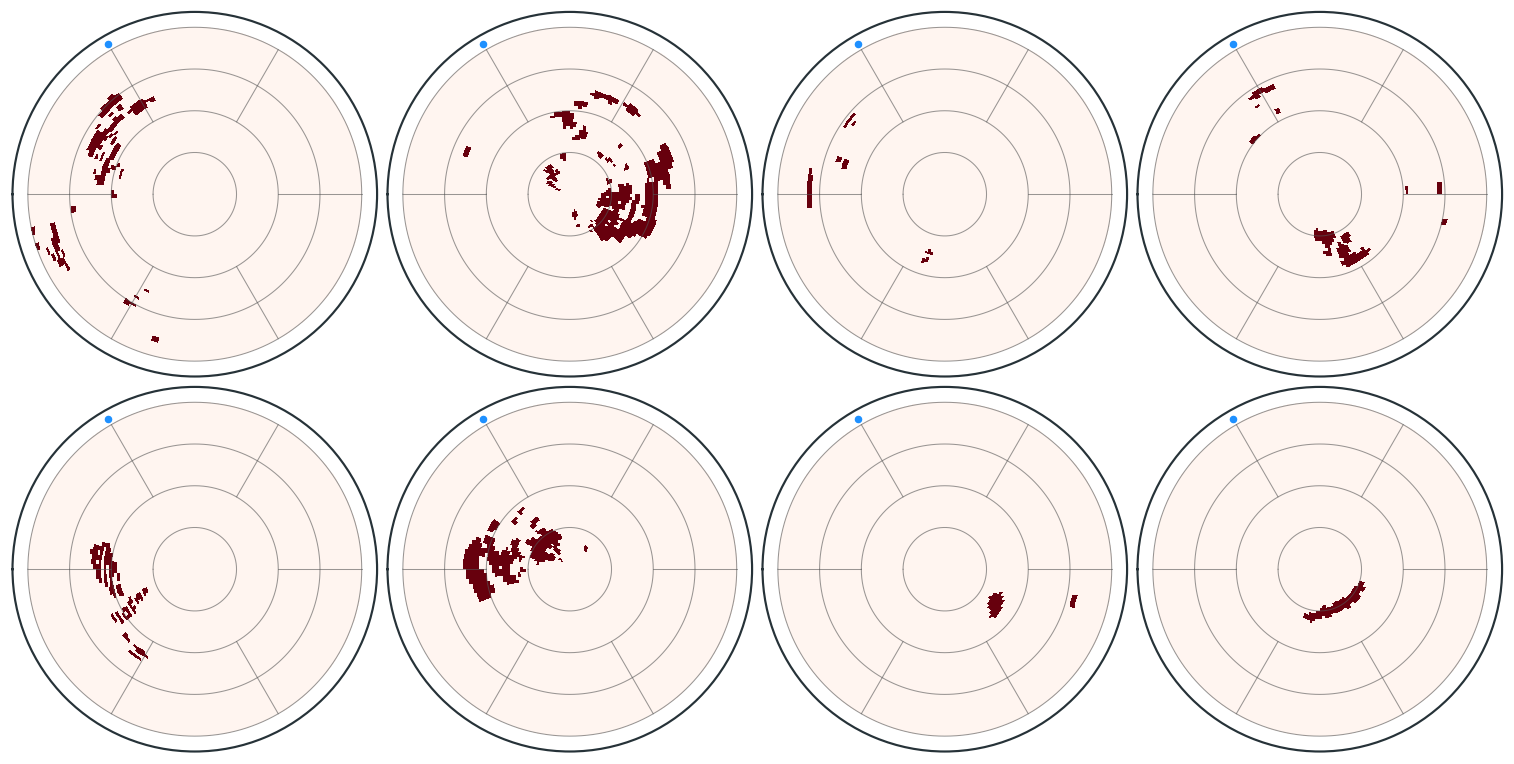

Saved fig2_retrieval_full.{pdf,png}


In [42]:
# ── Fig 2  Deterministic 1-NN retrieval — transposed grid ────────────────────
# Row 0 = Targets, Row 1 = Retrieved (1-NN)
# Paste variables from M05 into this cell or run after M05 scope is available:
#   df, X_best, pmaps, _best_vname, retrieve, draw_bullseye, RNG, FIGURES

_DET_N    = min(4, len(df))
_det_idx  = sorted(RNG.choice(len(df), size=_DET_N, replace=False).tolist())
_det_keys = [df.iloc[i]['key'] for i in _det_idx]

fig_det, axes_det = plt.subplots(
    2, _DET_N,
    figsize=(_DET_N * 3.0, 6.0),
    subplot_kw={'projection': 'polar'},
    constrained_layout=True,
)
# ensure shape (2, N) even when _DET_N == 1
if _DET_N == 1:
    axes_det = axes_det[:, np.newaxis]


# row labels via the leftmost axes

for col_i, (tgt_idx, tgt_key) in enumerate(zip(_det_idx, _det_keys)):
    mask_d         = np.ones(len(df), dtype=bool)
    mask_d[tgt_idx] = False
    base_idx_d     = np.where(mask_d)[0]

    top_local_d, top_dists_d, _ = retrieve(
        X_best[tgt_idx], X_best[mask_d], k=1, method='manhattan'
    )
    ret_global_d = base_idx_d[top_local_d[0]]
    ret_key_d    = df.iloc[ret_global_d]['key']
    tgt_map_d    = pmaps.get(tgt_key)
    ret_map_d    = pmaps.get(ret_key_d)
    tgt_pid_d    = tgt_key.split('/')[-1]
    ret_pid_d    = ret_key_d.split('/')[-1]

    # row 0 — target
    if tgt_map_d is not None:
        draw_bullseye(tgt_map_d, axes_det[0, col_i], title=None, cmap='Reds', vmax=1.0)
    else:
        pass  # no map

    # row 1 — retrieved
    if ret_map_d is not None:
        draw_bullseye(ret_map_d, axes_det[1, col_i], title=None, cmap='Reds', vmax=1.0)
    else:
        pass  # no map', fontsize=7)

fig_det.savefig(OUT / f'fig2_retrieval_{_best_vname}.pdf', bbox_inches='tight')
fig_det.savefig(OUT / f'fig2_retrieval_{_best_vname}.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved fig2_retrieval_{_best_vname}.{{pdf,png}}')

## Fig 2 – Axis selection: actual winner vs forced LV PC1

Cases where RV PC1 or LV PC2 beats LV PC1 in eccentricity score.  
**Top row:** actual chosen axis (green thick line, red sphere = apex).  
**Bottom row:** counterfactual with LV PC1 forced as axis (crimson).  
Thin lines = all candidate axes (blue = RV PC1, orange = LV PC1, purple = LV PC2).

Non-LV-PC1-winner cases collected: 6
  rendered: 02016806  winner=RV PC1
  rendered: 10008145  winner=RV PC1
  rendered: 11003916  winner=LV PC2
  rendered: 18030390  winner=LV PC2
  rendered: 19021225  winner=RV PC1
  rendered: 21005857  winner=RV PC1
All panels rendered.


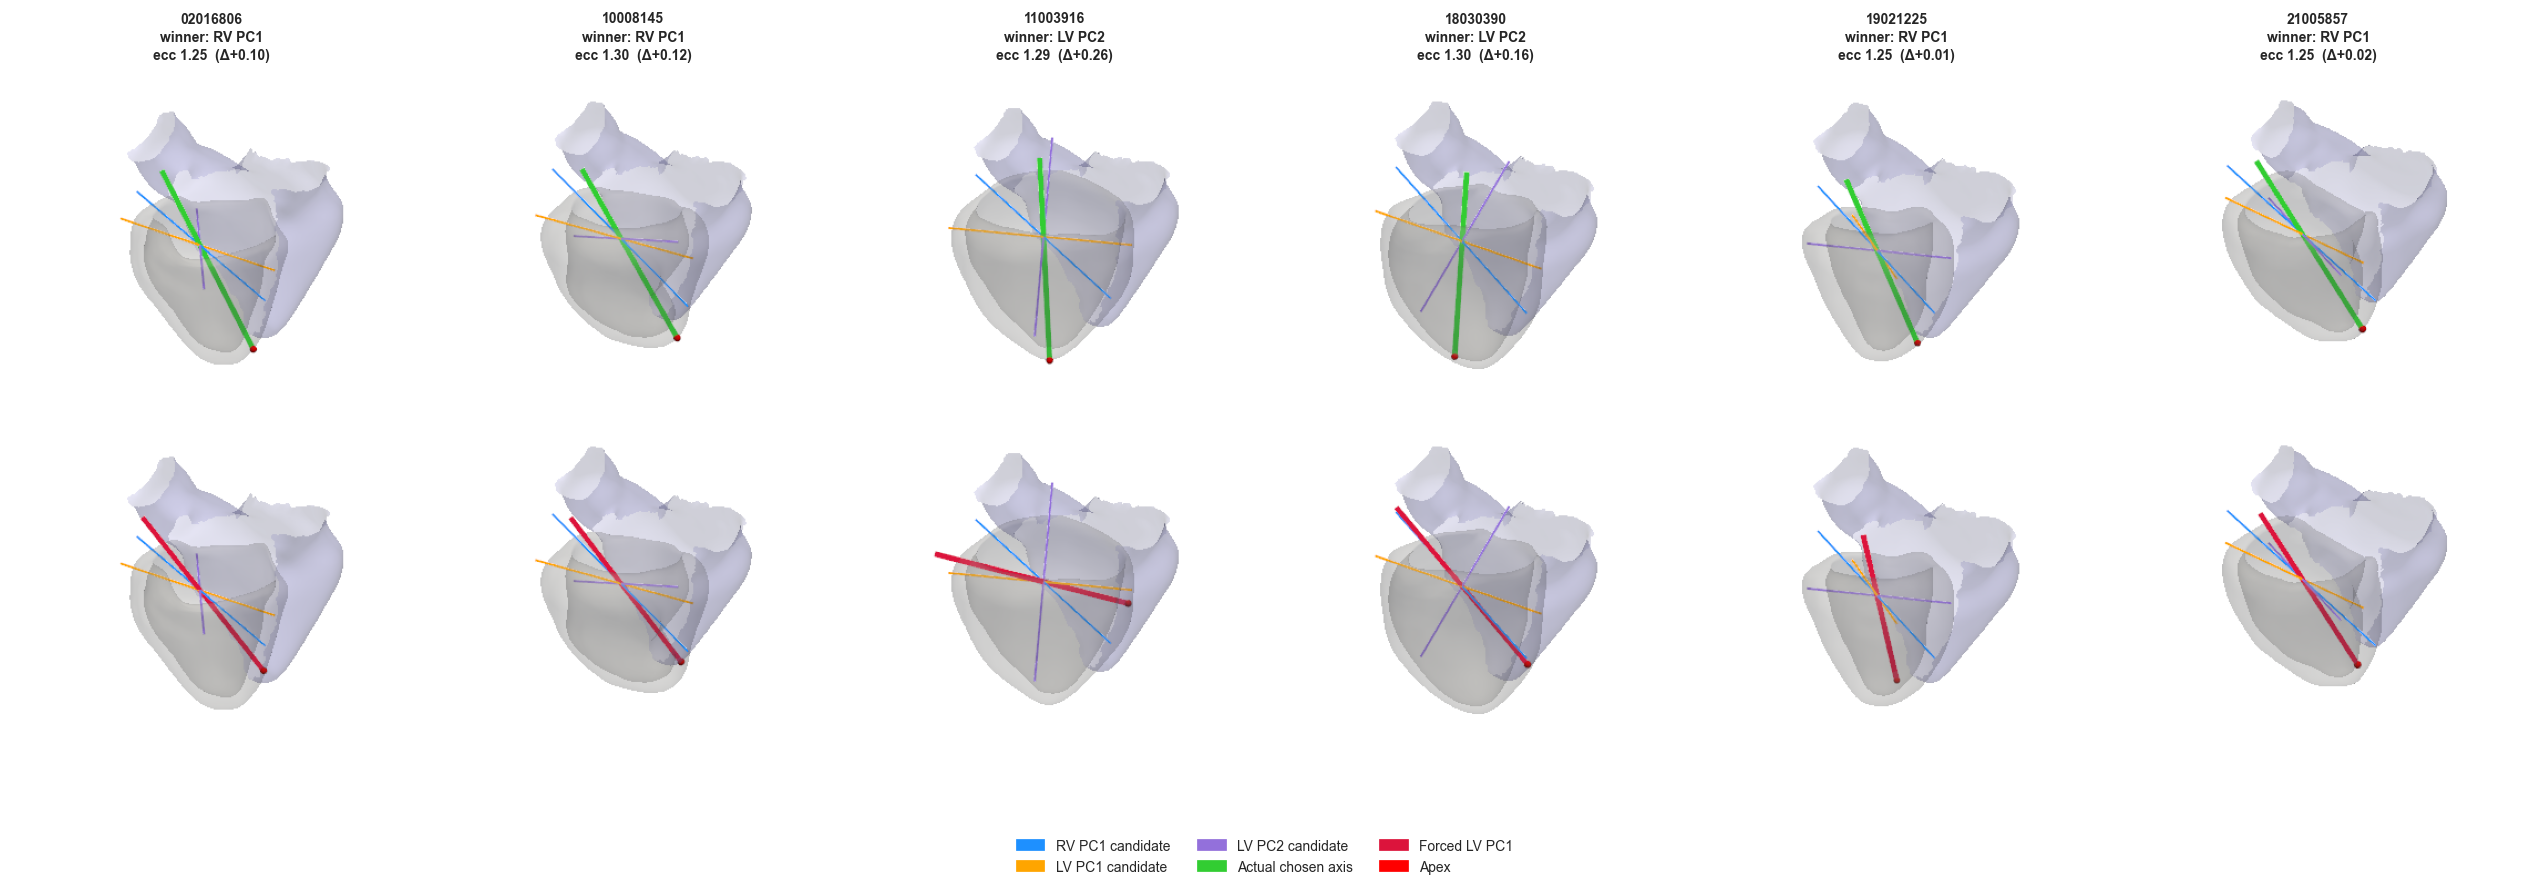

Saved: fig2_axis_winner_vs_pc1.png


In [43]:
from src.lv_geometry import _hull_apex_candidate

_F2_WIN   = (360, 300)   # off-screen render size per panel
_F2_MAX   = 6            # columns = cases to show
_CAND_COLORS = {'RV PC1': 'dodgerblue', 'LV PC1': 'orange', 'LV PC2': 'mediumpurple'}


def _f2_render_panel(shell, rv, pts, center, apex, axis, span, cands, ccolors, win_color):
    """Render one 3-D panel; return RGBA numpy array."""
    pl = pv.Plotter(off_screen=True, window_size=_F2_WIN)
    pl.set_background('white')
    pl.add_mesh(shell, color='#cccccc', opacity=0.18, smooth_shading=True, show_scalar_bar=False)
    if rv is not None:
        pl.add_mesh(rv, color='#aaaaff', opacity=0.25, smooth_shading=True, show_scalar_bar=False)
    for c_vec, c_col in zip(cands, ccolors):
        proj  = (pts - center) @ c_vec
        fspan = float(proj.max() - proj.min())
        line  = pv.Line(center - 0.5 * fspan * c_vec, center + 0.5 * fspan * c_vec)
        pl.add_mesh(line, color=c_col, line_width=2)
    rob_span = float(np.ptp((pts - apex) @ axis))
    pl.add_mesh(pv.Line(apex, apex + 1.1 * rob_span * axis), color=win_color, line_width=5)
    pl.add_mesh(pv.Sphere(radius=0.04 * span, center=apex), color='red',
                smooth_shading=True, show_scalar_bar=False)
    pl.view_isometric()
    pl.camera.zoom(1.15)
    img = pl.screenshot(None, return_img=True)
    pl.close()
    return img


# ── collect up to _F2_MAX non-LV-PC1-winner cases ────────────────────────────
_f2_entries = []

for _case in all_cases:
    if len(_f2_entries) >= _F2_MAX:
        break
    _shell = best_shell(_case)
    _rv    = best_rv_mesh(_case)
    if _shell is None:
        continue
    _pts    = np.asarray(_shell.points)
    _center = _pts.mean(axis=0)
    try:
        _, _sv, _vt = np.linalg.svd(_pts - _center, full_matrices=False)
        _cands, _clabels = [], []
        if _rv is not None:
            try:
                _rp  = np.asarray(_rv.points)
                _rc  = _rp.mean(axis=0)
                _, _, _rvt = np.linalg.svd(_rp - _rc, full_matrices=False)
                _cands.append(_rvt[0]); _clabels.append('RV PC1')
            except Exception:
                pass
        _cands.append(_vt[0]); _clabels.append('LV PC1')
        if len(_sv) > 1:
            _cands.append(_vt[1]); _clabels.append('LV PC2')

        _eccs, _apices = [], []
        for _c in _cands:
            _ap, _ecc, _ = _hull_apex_candidate(_pts, _center, _c)
            _eccs.append(_ecc); _apices.append(_ap)

        _wi = int(np.argmax(_eccs))
        if _clabels[_wi] == 'LV PC1':
            continue  # skip: LV PC1 already wins

        _lv_pc1_idx = _clabels.index('LV PC1')
        _f2_entries.append(dict(
            case=_case, shell=_shell, rv=_rv,
            pts=_pts, center=_center,
            cands=_cands, clabels=_clabels, eccs=_eccs, apices=_apices,
            winner_idx=_wi, lv_pc1_idx=_lv_pc1_idx,
        ))
    except Exception:
        pass

print(f'Non-LV-PC1-winner cases collected: {len(_f2_entries)}')

# ── render panels ─────────────────────────────────────────────────────────────
_f2_rows = []   # (img_actual, img_pc1, col_title)

for _e in _f2_entries:
    _pts    = _e['pts'];    _center = _e['center']
    _cands  = _e['cands']; _clabels = _e['clabels']
    _eccs   = _e['eccs'];  _apices  = _e['apices']
    _ccolors = [_CAND_COLORS.get(l, 'gray') for l in _clabels]
    _pid    = str(getattr(_e['case'], 'patient_id', 'unknown'))

    def _make_panel(idx, win_color):
        _ap   = _apices[idx]
        _vec  = _center - _ap
        _n    = np.linalg.norm(_vec)
        _ax   = _vec / _n if _n > 1e-9 else _cands[idx]
        _, _, _sp = _hull_apex_candidate(_pts, _center, _ax)
        return _f2_render_panel(_e['shell'], _e['rv'], _pts, _center,
                                _ap, _ax, _sp, _cands, _ccolors, win_color)

    _img_actual = _make_panel(_e['winner_idx'],  'limegreen')
    _img_pc1    = _make_panel(_e['lv_pc1_idx'],  'crimson')

    _wi = _e['winner_idx']; _pi = _e['lv_pc1_idx']
    _gap = _eccs[_wi] - _eccs[_pi]
    _col_title = f'{_pid}\nwinner: {_clabels[_wi]}\necc {_eccs[_wi]:.2f}  (Δ{_gap:+.2f})'
    _f2_rows.append((_img_actual, _img_pc1, _col_title))
    print(f'  rendered: {_pid}  winner={_clabels[_wi]}')

print('All panels rendered.')

# ── assemble 2 × N grid ───────────────────────────────────────────────────────
_nc = len(_f2_rows)
if _nc == 0:
    print('No non-LV-PC1 cases found.')
else:
    _fig2, _axes2 = plt.subplots(2, _nc, figsize=(_nc * 3.4, 2 * 3.4))
    _fig2.patch.set_facecolor('white')

    if _nc == 1:
        _axes2 = [[_axes2[0]], [_axes2[1]]]

    _ROW_LABELS = ['Actual chosen axis', 'Forced LV PC1']
    for _col, (_img_a, _img_p, _ctitle) in enumerate(_f2_rows):
        for _row, _img in enumerate([_img_a, _img_p]):
            _ax = _axes2[_row][_col]
            _ax.imshow(_img)
            _ax.axis('off')
            if _row == 0:
                _ax.set_title(_ctitle, fontsize=8, pad=4, linespacing=1.4)
        _axes2[0][0].set_ylabel(_ROW_LABELS[0], fontsize=9, labelpad=6)
        _axes2[1][0].set_ylabel(_ROW_LABELS[1], fontsize=9, labelpad=6)



    _legend2 = [
        mpatches.Patch(color='dodgerblue',   label='RV PC1 candidate'),
        mpatches.Patch(color='orange',        label='LV PC1 candidate'),
        mpatches.Patch(color='mediumpurple',  label='LV PC2 candidate'),
        mpatches.Patch(color='limegreen',     label='Actual chosen axis'),
        mpatches.Patch(color='crimson',       label='Forced LV PC1'),
        mpatches.Patch(color='red',           label='Apex'),
    ]
    _fig2.legend(handles=_legend2, loc='lower center', ncol=3,
                 fontsize=8, framealpha=0.9, bbox_to_anchor=(0.5, -0.05))

    plt.tight_layout(rect=[0, 0.06, 1, 1])
    _f2_path = OUT / 'fig2_axis_winner_vs_pc1.png'
    _fig2.savefig(_f2_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved: {_f2_path.name}')

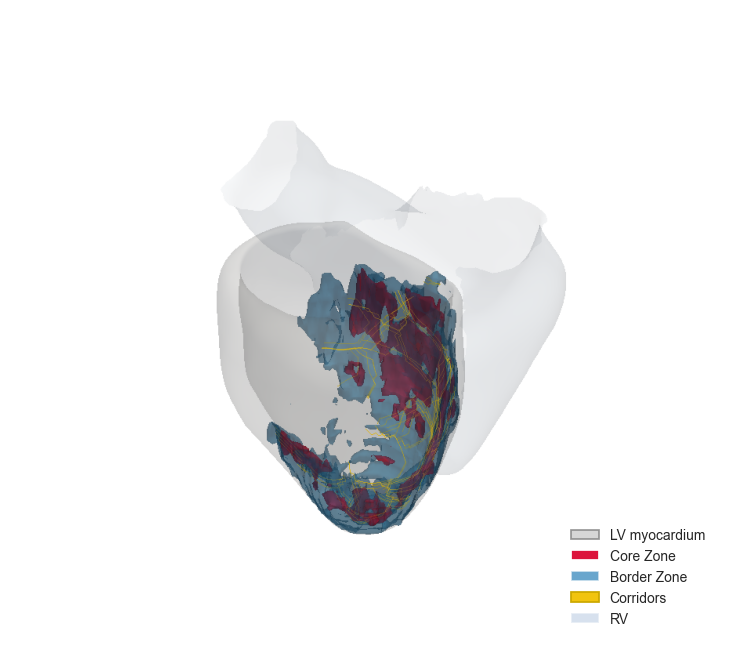

Saved: C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\lv-scar-segmentation\results\F01_figures\fig1b_representative_lv_iso.png


In [44]:
pl = pv.Plotter(off_screen=True, window_size=(900, 800))
pl.set_background('white')

if rv_mesh is not None:
    pl.add_mesh(rv_mesh, color=C_RV, opacity=OP_RV,
                smooth_shading=True, show_scalar_bar=False)

if lv_shell is not None:
    pl.add_mesh(lv_shell, color=C_SHELL, opacity=OP_SHELL,
                smooth_shading=True, show_scalar_bar=False)

if bz_mesh is not None:
    pl.add_mesh(bz_mesh, color=C_BZ, opacity=OP_BZ,
                smooth_shading=True, show_scalar_bar=False)

if cz_mesh is not None:
    pl.add_mesh(cz_mesh, color=C_CZ, opacity=OP_CZ,
                smooth_shading=True, show_scalar_bar=False)

_add_corridors(pl)

pl.view_isometric()
img_iso = pl.screenshot(None, return_img=True)
pl.close()

fig, ax = plt.subplots(figsize=(6, 6))
fig.patch.set_facecolor('white')
ax.imshow(img_iso)
ax.axis('off')

legend_items = [
    mpatches.Patch(facecolor=C_SHELL, edgecolor='gray', alpha=0.8, label='LV myocardium'),
    mpatches.Patch(facecolor=C_CZ,   label='Core Zone'),
    mpatches.Patch(facecolor=C_BZ,   alpha=0.7, label='Border Zone'),
    mpatches.Patch(facecolor=C_CORR, edgecolor='#cba800', label='Corridors'),
    mpatches.Patch(facecolor=C_RV,   alpha=0.5, label='RV'),
]

ax.legend(
    handles=legend_items,
    loc='lower right',
    fontsize=8,
    framealpha=0.9,
)

plt.tight_layout()
out_path_iso = OUT / 'fig1b_representative_lv_iso.png'
fig.savefig(out_path_iso, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {out_path_iso}')

## Fig 3 – Population superposition

AHA bull's-eye polar maps aggregated across all cases with LV shell + Core Zone.  
**Left:** vertex scar frequency. **Centre:** mean CZ area (mm²). **Right:** normalised CZ/LV area coverage.

OK: 105   failures: 0


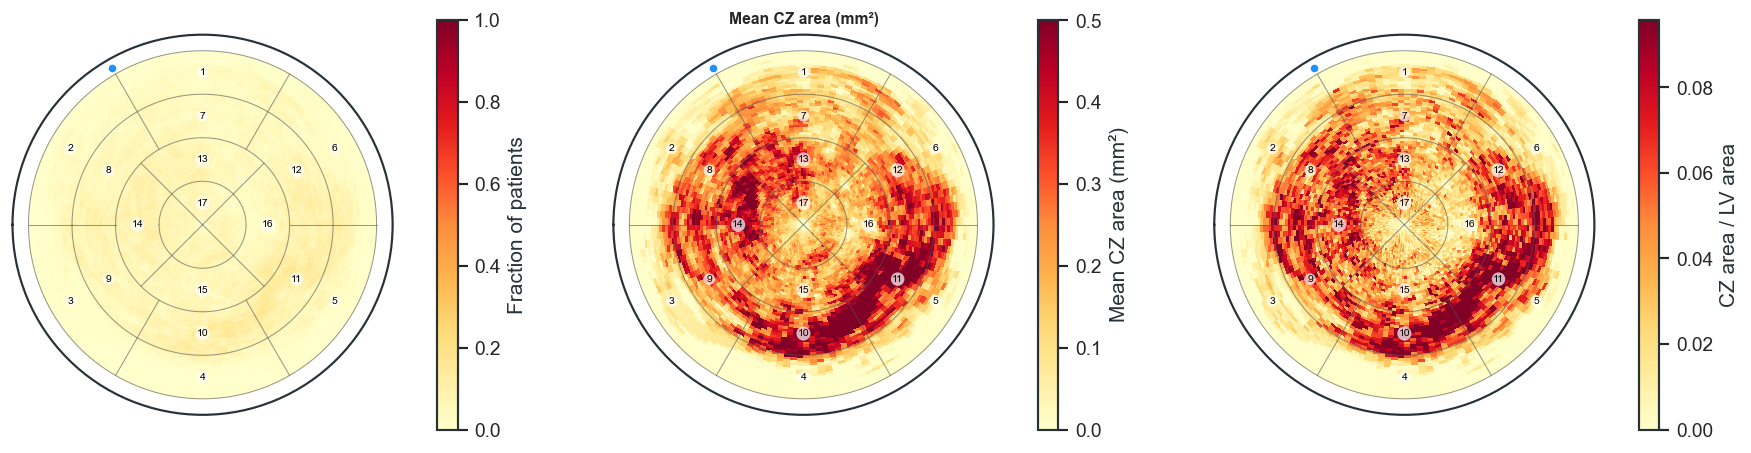

Saved: fig3_population_superposition.png  (n=105)


In [45]:
from src.mesh_utils import get_cz_mesh
from src.lv_geometry import (
    prepare_polar_geometry,
    project_points_to_polar,
    polar_mask,
    rv_reference_from_rv_mesh,
)

# ── constants ─────────────────────────────────────────────────────────────────
_F3_N_R     = 64
_F3_N_THETA = 128
_F3_EPS     = 1e-12
_F3_CMAP    = 'YlOrRd'


# ── bull's-eye grid helpers ───────────────────────────────────────────────────
def _f3_draw_grid(ax):
    _t = np.linspace(0, 2 * np.pi, 361)
    for _r in (0.25, 0.50, 0.75, 1.0):
        ax.plot(_t, np.full_like(_t, _r), color='#555', lw=0.6, alpha=0.6)
    for _deg in (0, 60, 120, 180, 240, 300):
        ax.plot([np.deg2rad(_deg)] * 2, [0.5, 1.0], color='#555', lw=0.6, alpha=0.6)
    for _deg in (45, 135, 225, 315):
        ax.plot([np.deg2rad(_deg)] * 2, [0.0, 0.5], color='#555', lw=0.6, alpha=0.6)
    ax.set_theta_zero_location('W')
    ax.set_theta_direction(-1)
    ax.set_rticks([])
    ax.set_xticks([])
    ax.scatter([np.deg2rad(60)], [1.04], s=26, color='dodgerblue',
               edgecolor='white', linewidth=0.7, zorder=10, clip_on=False)


_F3_AHA_LABELS = (
    (1, 90, 0.875), (2, 30, 0.875), (3, 330, 0.875),
    (4, 270, 0.875), (5, 210, 0.875), (6, 150, 0.875),
    (7, 90, 0.625), (8, 30, 0.625), (9, 330, 0.625),
    (10, 270, 0.625), (11, 210, 0.625), (12, 150, 0.625),
    (13, 90, 0.375), (14, 0, 0.375), (15, 270, 0.375),
    (16, 180, 0.375), (17, 90, 0.125),
)


def _f3_draw_bullseye(data, ax, title=None, cmap=_F3_CMAP, vmax=None):
    arr = np.asarray(data, dtype=float)
    if vmax is None:
        vmax = max(float(np.nanmax(arr)), _F3_EPS)
    T, R = np.meshgrid(
        np.linspace(0, 2 * np.pi, arr.shape[1] + 1),
        np.linspace(0, 1.0,       arr.shape[0] + 1),
    )
    ax.set_theta_zero_location('W')
    ax.set_theta_direction(-1)
    mesh = ax.pcolormesh(T, R, arr, cmap=cmap, vmin=0, vmax=vmax, shading='flat')
    _f3_draw_grid(ax)
    for seg, deg, r in _F3_AHA_LABELS:
        ax.text(np.deg2rad(deg % 360), r, str(seg), fontsize=6,
                ha='center', va='center', color='black',
                bbox=dict(boxstyle='circle,pad=0.12', facecolor='white',
                          edgecolor='none', alpha=0.7))
    if title:
        ax.set_title(title, fontsize=9, pad=6)
    return mesh


def _f3_pct_vmax(arr, pct=95, default=1.0):
    vals = np.asarray(arr)[np.isfinite(arr) & (np.asarray(arr) > 0)]
    return float(np.nanpercentile(vals, pct)) if len(vals) else default


# ── triangle area accumulation ────────────────────────────────────────────────
def _f3_tri_areas_centers(mesh):
    surf  = mesh.extract_surface().clean()
    pts   = np.asarray(surf.points, dtype=float)
    faces = np.asarray(surf.faces)
    cents, areas = [], []
    i = 0
    while i < len(faces):
        n   = int(faces[i]); idx = faces[i + 1: i + 1 + n]; i += 1 + n
        for a, b, c in ([(0, 1, 2)] if n == 3 else [(0, 1, 2), (0, 2, 3)]):
            A, B, C = pts[idx[a]], pts[idx[b]], pts[idx[c]]
            area = 0.5 * np.linalg.norm(np.cross(B - A, C - A))
            if area > 0:
                cents.append((A + B + C) / 3.0); areas.append(area)
    return np.array(cents), np.array(areas)


def _f3_accum_area(mesh, geom):
    centers, areas = _f3_tri_areas_centers(mesh)
    theta, s = project_points_to_polar(centers, geom)
    theta = (2.0 * np.pi - theta) % (2.0 * np.pi)
    ri = np.clip((s * _F3_N_R).astype(int),                       0, _F3_N_R - 1)
    ti = np.clip((theta / (2 * np.pi) * _F3_N_THETA).astype(int), 0, _F3_N_THETA - 1)
    grid = np.zeros((_F3_N_R, _F3_N_THETA), dtype=float)
    np.add.at(grid, (ri, ti), areas)
    return grid[:, ::-1]


def _f3_polar_maps(case):
    shell = best_shell(case)
    cz    = get_cz_mesh(case)
    rv    = best_rv_mesh(case)
    if shell is None or cz is None:
        raise ValueError('missing shell or CZ')
    if rv is not None:
        ref_fn = lambda m, ax, ap, _rv=rv: rv_reference_from_rv_mesh(m, _rv, ax, ap)
        geom   = prepare_polar_geometry(shell, ref_fn=ref_fn, rv_mesh=rv)
    else:
        geom = prepare_polar_geometry(shell, rv_mesh=None)

    cz_pts  = np.asarray(cz.points)
    t_cw    = (2.0 * np.pi - project_points_to_polar(cz_pts, geom)[0]) % (2.0 * np.pi)
    vertex  = polar_mask(t_cw, project_points_to_polar(cz_pts, geom)[1],
                         _F3_N_R, _F3_N_THETA).astype(float)

    cz_area = _f3_accum_area(cz,    geom)
    lv_area = _f3_accum_area(shell, geom)
    coverage = np.divide(cz_area, lv_area,
                         out=np.zeros_like(cz_area), where=lv_area > _F3_EPS)
    return dict(vertex=vertex, cz_area=cz_area, coverage=coverage)


# ── compute maps for all valid cases ─────────────────────────────────────────
_f3_results = {}
_f3_fails   = []

_f3_known = [c for c in all_cases
             if c.tissue_surfaces.get('core') is not None and best_shell(c) is not None]

for _case in _f3_known:
    _key = f'{_case.year}/{_case.patient_id}'
    try:
        _f3_results[_key] = _f3_polar_maps(_case)
    except Exception as _exc:
        _f3_fails.append(_key)

print(f'OK: {len(_f3_results)}   failures: {len(_f3_fails)}')

# ── mean stacks ───────────────────────────────────────────────────────────────
_f3_keys       = list(_f3_results.keys())
_f3_vert_freq  = np.stack([_f3_results[k]['vertex']   for k in _f3_keys]).mean(axis=0)
_f3_mean_area  = np.stack([_f3_results[k]['cz_area']  for k in _f3_keys]).mean(axis=0)
_f3_mean_cov   = np.stack([_f3_results[k]['coverage'] for k in _f3_keys]).mean(axis=0)

_f3_vmax_vert = 1.0
_f3_vmax_area = _f3_pct_vmax(_f3_mean_area, 95)
_f3_vmax_cov  = _f3_pct_vmax(_f3_mean_cov,  95)

# ── plot ──────────────────────────────────────────────────────────────────────
_fig3, _axes3 = plt.subplots(1, 3, figsize=(17, 6.0), subplot_kw={'projection': 'polar'})
_fig3.patch.set_facecolor('white')

_m1 = _f3_draw_bullseye(_f3_vert_freq, _axes3[0], None,      cmap=_F3_CMAP, vmax=_f3_vmax_vert)
_m2 = _f3_draw_bullseye(_f3_mean_area, _axes3[1], 'Mean CZ area (mm²)',    cmap=_F3_CMAP, vmax=_f3_vmax_area)
_m3 = _f3_draw_bullseye(_f3_mean_cov,  _axes3[2], None, cmap=_F3_CMAP, vmax=_f3_vmax_cov)

_cbar_labels = ['Fraction of patients', 'Mean CZ area (mm²)', 'CZ area / LV area']
for _m, _ax, _lab in zip([_m1, _m2, _m3], _axes3, _cbar_labels):
    plt.colorbar(_m, ax=_ax, fraction=0.046, pad=0.10, label=_lab)

_fig3.subplots_adjust(top=0.88, wspace=0.35)
_f3_path = OUT / 'fig3_population_superposition.png'
_fig3.savefig(_f3_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {_f3_path.name}  (n={len(_f3_keys)})')

## Fig 4 – Resolution exploration

Vertex scar maps for three representative cases at three polar-grid resolutions,
plus population-mean maps at the same resolutions.  
**Rows 1–3:** per-patient at coarse (32×64), fine (128×256), and original (64×128).  
**Row 4:** population mean at each resolution.

Cases: ['2021/02026677', '2021/03005263', '2021/10012086']
  pop (32, 64): n=105  mean=0.0757
  pop (64, 128): n=105  mean=0.0512
  pop (128, 256): n=105  mean=0.0326


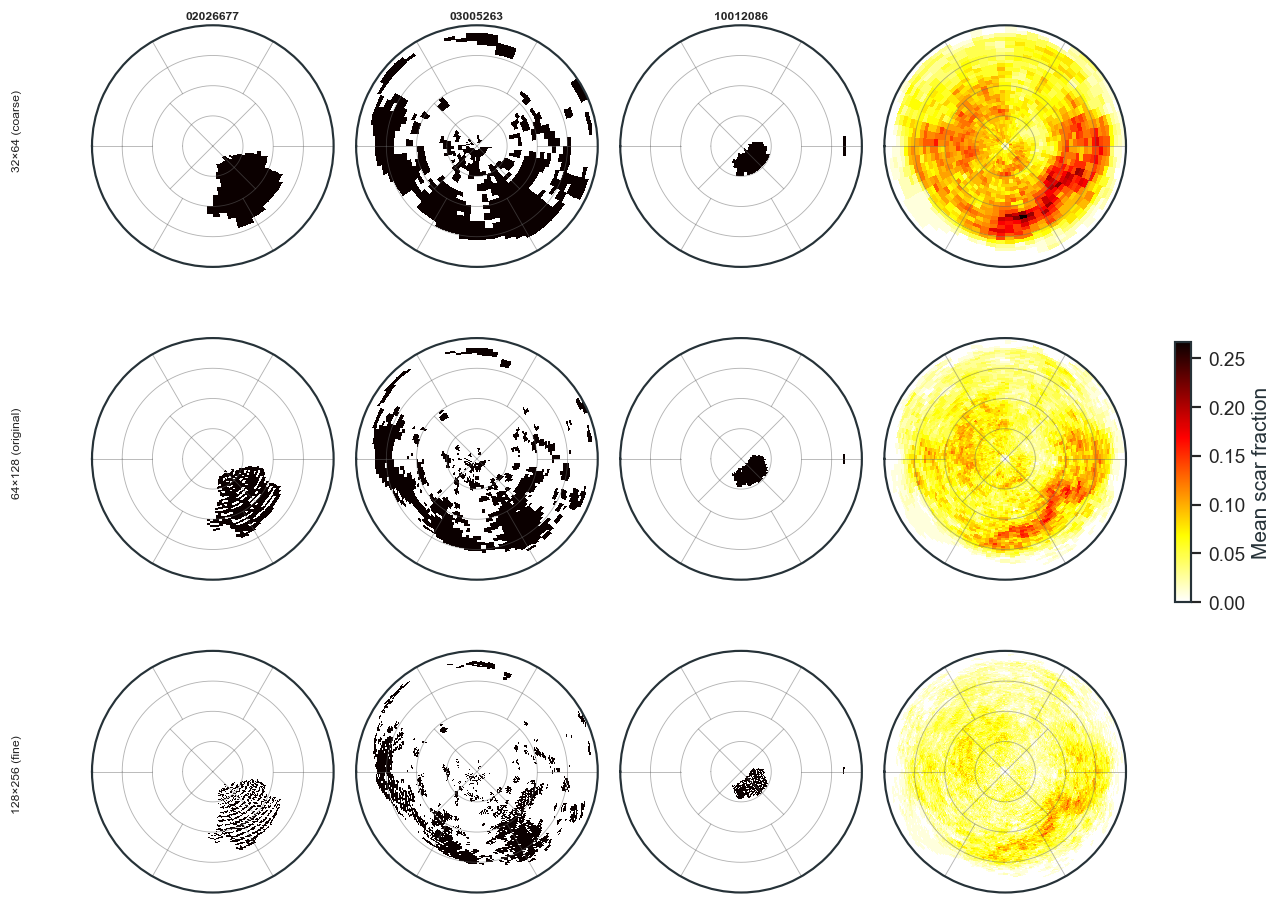

Saved: fig4_resolution_exploration.png


In [46]:
# ── imports ───────────────────────────────────────────────────────────────────
from src.mesh_utils import get_cz_mesh
from src.lv_geometry import (
    prepare_polar_geometry,
    project_points_to_polar,
    polar_mask,
    rv_reference_from_rv_mesh,
)

# ── resolution triplet ────────────────────────────────────────────────────────
_F4_COARSE = (32,  64)
_F4_ORIG   = (64,  128)
_F4_FINE   = (128, 256)
_F4_RESOLUTIONS = [_F4_COARSE, _F4_ORIG, _F4_FINE]
_F4_RES_LABELS  = {_F4_COARSE: '32×64 (coarse)',
                   _F4_ORIG:   '64×128 (original)',
                   _F4_FINE:   '128×256 (fine)'}
_F4_NCASES = 3


# ── vertex-map builder ────────────────────────────────────────────────────────
def _f4_vertex_map(case, n_r, n_theta):
    shell = best_shell(case)
    cz    = get_cz_mesh(case)
    rv    = best_rv_mesh(case)
    if shell is None or cz is None:
        raise ValueError('missing shell or CZ')
    if rv is not None:
        ref_fn = lambda m, ax, ap, _rv=rv: rv_reference_from_rv_mesh(m, _rv, ax, ap)
        geom   = prepare_polar_geometry(shell, ref_fn=ref_fn, rv_mesh=rv)
    else:
        geom = prepare_polar_geometry(shell, rv_mesh=None)
    theta, s = project_points_to_polar(np.asarray(cz.points), geom)
    theta = (2.0 * np.pi - theta) % (2.0 * np.pi)
    return polar_mask(theta, s, n_r, n_theta).astype(float)


# ── bull's-eye renderer ───────────────────────────────────────────────────────
def _f4_draw(ax, arr, title, cmap='hot_r', vmax=None):
    arr  = np.asarray(arr, dtype=float)
    vmax = vmax if vmax is not None else max(float(np.nanmax(arr)), 1e-9)
    T, R = np.meshgrid(
        np.linspace(0, 2 * np.pi, arr.shape[1] + 1),
        np.linspace(0, 1.0,       arr.shape[0] + 1),
    )
    ax.set_theta_zero_location('W')
    ax.set_theta_direction(-1)
    mesh = ax.pcolormesh(T, R, np.nan_to_num(arr), cmap=cmap, vmin=0, vmax=vmax,
                         shading='flat')
    _t = np.linspace(0, 2 * np.pi, 361)
    for _r in (0.25, 0.50, 0.75, 1.0):
        ax.plot(_t, np.full_like(_t, _r), color='#666', lw=0.5, alpha=0.5)
    for _d in (0, 60, 120, 180, 240, 300):
        ax.plot([np.deg2rad(_d)] * 2, [0.5, 1.0], color='#666', lw=0.5, alpha=0.5)
    for _d in (45, 135, 225, 315):
        ax.plot([np.deg2rad(_d)] * 2, [0.0, 0.5], color='#666', lw=0.5, alpha=0.5)
    ax.set_rticks([]); ax.set_xticks([])
    if title:
        ax.set_title(title, fontsize=7, pad=3)
    return mesh


# ── collect cases ─────────────────────────────────────────────────────────────
_f4_known = [c for c in all_cases
             if c.tissue_surfaces.get('core') is not None and best_shell(c) is not None]

_f4_case_keys = []
for _c in _f4_known:
    if len(_f4_case_keys) >= _F4_NCASES:
        break
    try:
        if _f4_vertex_map(_c, *_F4_ORIG).mean() > 0.01:
            _f4_case_keys.append(f'{_c.year}/{_c.patient_id}')
    except Exception:
        pass

if len(_f4_case_keys) < _F4_NCASES:
    _f4_all_keys = [f'{c.year}/{c.patient_id}' for c in _f4_known]
    for _k in _f4_all_keys:
        if _k not in _f4_case_keys:
            _f4_case_keys.append(_k)
        if len(_f4_case_keys) >= _F4_NCASES:
            break
_f4_case_keys = _f4_case_keys[:_F4_NCASES]
_f4_case_map  = {f'{c.year}/{c.patient_id}': c for c in _f4_known}
print(f'Cases: {_f4_case_keys}')

# ── compute maps ──────────────────────────────────────────────────────────────
_f4_case_maps = {}
for _key in _f4_case_keys:
    _f4_case_maps[_key] = {}
    for _res in _F4_RESOLUTIONS:
        try:
            _f4_case_maps[_key][_res] = _f4_vertex_map(_f4_case_map[_key], *_res)
        except Exception as _e:
            print(f'  skip {_key} {_res}: {_e}')

_f4_pop = {}
for _res in _F4_RESOLUTIONS:
    _stack = []
    for _case in _f4_known:
        try:
            _stack.append(_f4_vertex_map(_case, *_res))
        except Exception:
            pass
    if _stack:
        _f4_pop[_res] = np.stack(_stack).mean(axis=0)
        print(f'  pop {_res}: n={len(_stack)}  mean={_f4_pop[_res].mean():.4f}')

# ── 3 × 4 figure: rows=resolution, cols=patient0/1/2/pop-mean ────────────────
# Row order (top→bottom): coarse, original, fine
_ROW_RES   = [_F4_COARSE, _F4_ORIG, _F4_FINE]
_ROW_LBLS  = [_F4_RES_LABELS[r] for r in _ROW_RES]
_COL_LBLS  = [k.split('/')[-1] for k in _f4_case_keys] + ['Pop. mean']

_f4_vmax_pt  = 1.0
_f4_vmax_pop = max(
    (float(np.nanmax(_f4_pop[r])) for r in _ROW_RES if r in _f4_pop),
    default=1.0,
)

_fig4, _axes4 = plt.subplots(
    3, 4,
    figsize=(4 * 2.6, 3 * 2.6),
    subplot_kw={'projection': 'polar'},
)
_fig4.patch.set_facecolor('white')

_msh = None
for _row, _res in enumerate(_ROW_RES):
    # patient columns
    for _col, _key in enumerate(_f4_case_keys):
        _ax  = _axes4[_row, _col]
        _arr = _f4_case_maps.get(_key, {}).get(_res)
        _ttl = _COL_LBLS[_col] if _row == 0 else ''
        if _arr is not None:
            _f4_draw(_ax, _arr, title=_ttl, cmap='hot_r', vmax=_f4_vmax_pt)
        else:
            _ax.set_title('N/A', fontsize=6)
    # population mean column (col 3)
    _ax  = _axes4[_row, 3]
    _arr = _f4_pop.get(_res)
    _ttl = ''
    if _arr is not None:
        _msh = _f4_draw(_ax, _arr, title=_ttl, cmap='hot_r', vmax=_f4_vmax_pop)
    else:
        _ax.set_title('N/A', fontsize=6)

# row labels on the left
for _lbl, _y in zip(_ROW_LBLS, [0.83, 0.50, 0.17]):
    _fig4.text(0.01, _y, _lbl, fontsize=7, va='center', rotation=90,
               ha='center', color='#222')

plt.tight_layout(rect=[0.05, 0, 0.88, 1])

# colorbar spanning one row height, centered vertically
if _msh is not None:
    _one_row_h = 0.80 / 3          # ≈ 0.267 — height of one subplot row
    _cbar_bot  = 0.08 + 0.80 / 2 - _one_row_h / 2   # centred on middle row
    _cbar_ax = _fig4.add_axes([0.90, _cbar_bot, 0.013, _one_row_h])
    _fig4.colorbar(_msh, cax=_cbar_ax, label='Mean scar fraction')

_f4_path = OUT / 'fig4_resolution_exploration.png'
_fig4.savefig(_f4_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {_f4_path.name}')

## Fig 5 – Population scar map + coronary territory overlay

Left: population mean vertex scar frequency. Right: same map with AHA coronary territory overlay (LAD / RCA / LCX).

pmaps built: 105


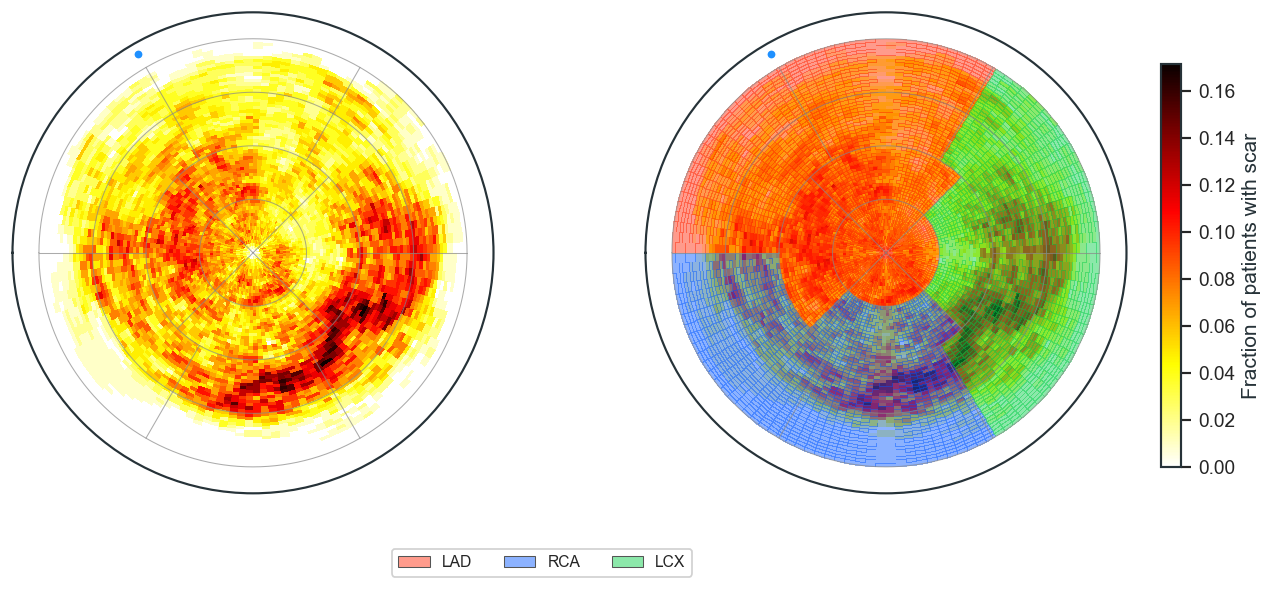

Saved: fig5_population_scar_territory.png  (n=105)


In [47]:
import matplotlib.colors as mcolors
from src.mesh_utils import get_cz_mesh
from src.lv_geometry import (
    prepare_polar_geometry,
    project_points_to_polar,
    polar_mask,
    rv_reference_from_rv_mesh,
)

# ── grid constants ─────────────────────────────────────────────────────────────
_F5_N_R     = 64
_F5_N_THETA = 128

# ── AHA-17 segment → coronary territory grid ──────────────────────────────────
def _f5_aha_grid(n_r=_F5_N_R, n_theta=_F5_N_THETA):
    lbl = np.zeros((n_r, n_theta), dtype=np.int64)
    rc  = (np.arange(n_r) + 0.5) / n_r
    tc  = (np.arange(n_theta) + 0.5) / n_theta * 360.0
    for ri, radius in enumerate(rc):
        for ti, theta_deg in enumerate(tc):
            if radius < 0.25:
                lbl[ri, ti] = 17
            elif radius < 0.50:
                lbl[ri, ti] = (13 if 45 <= theta_deg < 135  else
                               16 if 135 <= theta_deg < 225 else
                               15 if 225 <= theta_deg < 315 else 14)
            elif radius < 0.75:
                lbl[ri, ti] = (8  if 0   <= theta_deg < 60  else
                               7  if 60  <= theta_deg < 120 else
                               12 if 120 <= theta_deg < 180 else
                               11 if 180 <= theta_deg < 240 else
                               10 if 240 <= theta_deg < 300 else 9)
            else:
                lbl[ri, ti] = (2  if 0   <= theta_deg < 60  else
                               1  if 60  <= theta_deg < 120 else
                               6  if 120 <= theta_deg < 180 else
                               5  if 180 <= theta_deg < 240 else
                               4  if 240 <= theta_deg < 300 else 3)
    return lbl

_F5_TERRITORY = {'LAD': [1, 2, 7, 8, 13, 14, 17],
                 'RCA': [3, 4, 9, 10, 15],
                 'LCX': [5, 6, 11, 12, 16]}

_F5_AHA  = _f5_aha_grid()
_F5_TGRID = np.full((_F5_N_R, _F5_N_THETA), '', dtype=object)
for _t, _segs in _F5_TERRITORY.items():
    for _s in _segs:
        _F5_TGRID[_F5_AHA == _s] = _t

# ── build pmaps (vertex polar maps) ──────────────────────────────────────────
def _f5_vertex_map(case):
    shell = best_shell(case)
    cz    = get_cz_mesh(case)
    rv    = best_rv_mesh(case)
    if shell is None or cz is None:
        raise ValueError('missing')
    if rv is not None:
        ref_fn = lambda m, ax, ap, _rv=rv: rv_reference_from_rv_mesh(m, _rv, ax, ap)
        geom   = prepare_polar_geometry(shell, ref_fn=ref_fn, rv_mesh=rv)
    else:
        geom = prepare_polar_geometry(shell, rv_mesh=None)
    theta, s = project_points_to_polar(np.asarray(cz.points), geom)
    theta = (2.0 * np.pi - theta) % (2.0 * np.pi)
    return polar_mask(theta, s, _F5_N_R, _F5_N_THETA).astype(float)

_f5_known = [c for c in all_cases
             if c.tissue_surfaces.get('core') is not None and best_shell(c) is not None]

_f5_pmaps = {}
for _case in _f5_known:
    _key = f'{_case.year}/{_case.patient_id}'
    try:
        _f5_pmaps[_key] = _f5_vertex_map(_case)
    except Exception:
        pass

print(f'pmaps built: {len(_f5_pmaps)}')

# ── population mean ───────────────────────────────────────────────────────────
_f5_pop_mean = np.stack(list(_f5_pmaps.values())).mean(axis=0)
_f5_vmax     = max(float(np.nanmax(_f5_pop_mean)), 1e-9)
_n           = len(_f5_pmaps)

# ── bull's-eye decorator ──────────────────────────────────────────────────────
_F5_OVERLAY = {'LAD': '#ff2200', 'RCA': '#0055ff', 'LCX': '#00cc44'}
_F5_ALPHA   = 0.45

_F5_T = np.linspace(0, 2 * np.pi, _F5_N_THETA + 1)
_F5_R = np.linspace(0, 1.0,       _F5_N_R     + 1)
_F5_TM, _F5_RM = np.meshgrid(_F5_T, _F5_R)


def _f5_decorate(ax):
    """Grid lines, cardinal labels, blue dot at 60° (upper RV insertion)."""
    t_full = np.linspace(0, 2 * np.pi, 361)
    for _rb in (0.25, 0.50, 0.75, 1.0):
        ax.plot(t_full, np.full_like(t_full, _rb), color='#888', lw=0.6, alpha=0.7)
    for _d in (0, 60, 120, 180, 240, 300):
        ax.plot([np.deg2rad(_d)] * 2, [0.5, 1.0], color='#888', lw=0.6, alpha=0.7)
    for _d in (45, 135, 225, 315):
        ax.plot([np.deg2rad(_d)] * 2, [0.0, 0.5], color='#888', lw=0.6, alpha=0.7)
    ax.set_theta_zero_location('W')
    ax.set_theta_direction(-1)
    ax.set_rticks([]); ax.set_xticks([])
    # blue dot: upper RV insertion (anteroseptal boundary, ~11 o'clock, 60°)
    ax.scatter([np.deg2rad(60)], [1.07], s=28, color='dodgerblue',
               edgecolor='white', linewidth=0.8, zorder=10, clip_on=False)
    # cardinal labels
    for _lbl, _deg in [('ANT', 90), ('SEP', 0), ('INF', 270), ('LAT', 180)]:
        ax.annotate(_lbl, xy=(np.deg2rad(_deg), 1.17), ha='center', va='center',
                    fontsize=8, fontweight='bold', color='#333', xycoords='data')


# ── figure ────────────────────────────────────────────────────────────────────
_fig5, _axes5 = plt.subplots(
    1, 2,
    figsize=(11, 5.2),
    subplot_kw={'projection': 'polar'},
    constrained_layout=False,
)
_fig5.patch.set_facecolor('white')

# ── left: scar frequency only ────────────────────────────────────────────────
_mesh5 = _axes5[0].pcolormesh(_F5_TM, _F5_RM, _f5_pop_mean,
                               cmap='hot_r', vmin=0, vmax=_f5_vmax, shading='flat')
_f5_decorate(_axes5[0])

# ── right: scar + territory overlay ──────────────────────────────────────────
_axes5[1].pcolormesh(_F5_TM, _F5_RM, _f5_pop_mean,
                     cmap='hot_r', vmin=0, vmax=_f5_vmax, shading='flat')
for _terr, _color in _F5_OVERLAY.items():
    _val = (_F5_TGRID == _terr).astype(float)
    _cmap_t = mcolors.LinearSegmentedColormap.from_list(
        _terr,
        [(1, 1, 1, 0.0), (*mcolors.to_rgb(_color), _F5_ALPHA)],
    )
    _axes5[1].pcolormesh(_F5_TM, _F5_RM, _val, cmap=_cmap_t,
                         vmin=0, vmax=1, shading='flat')
_f5_decorate(_axes5[1])

# ── shared colorbar (explicit cax, avoids shrinking axes) ────────────────────
_fig5.subplots_adjust(left=0.04, right=0.86, top=0.88, bottom=0.14, wspace=0.28)
_cbar5_ax = _fig5.add_axes([0.88, 0.18, 0.015, 0.62])
_fig5.colorbar(_mesh5, cax=_cbar5_ax, label='Fraction of patients with scar')

# ── territory legend ──────────────────────────────────────────────────────────
_patches5 = [
    mpatches.Patch(facecolor=mcolors.to_rgba(_F5_OVERLAY[t], alpha=_F5_ALPHA),
                   edgecolor='#555', linewidth=0.6, label=t)
    for t in _F5_TERRITORY
]
_fig5.legend(handles=_patches5, loc='lower center', ncol=3,
             fontsize=9, frameon=True, framealpha=0.9,
             bbox_to_anchor=(0.43, 0.00))

_f5_path = OUT / 'fig5_population_scar_territory.png'
_fig5.savefig(_f5_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {_f5_path.name}  (n={_n})')

## Fig 5b – Population scar frequency (single panel)

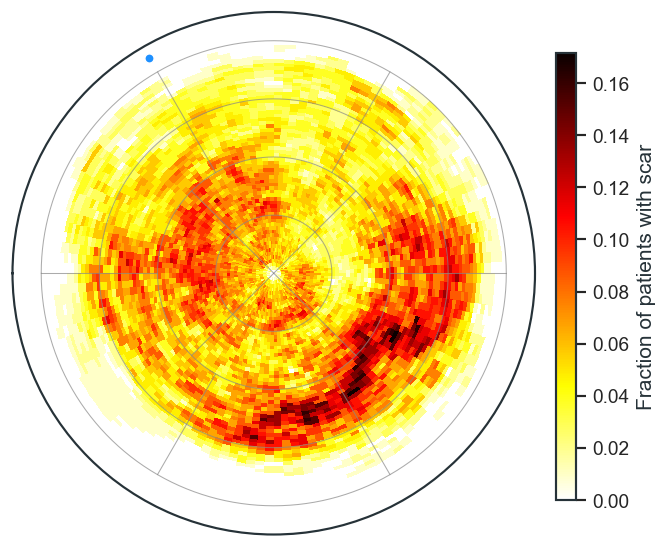

Saved: fig5b_population_scar_frequency.png  (n=105)


In [48]:
# ── Fig 5b – Population scar frequency, single polar panel ───────────────────
_fig5b, _ax5b = plt.subplots(1, 1, figsize=(5.5, 5.5),
                              subplot_kw={'projection': 'polar'})
_fig5b.patch.set_facecolor('white')

_mesh5b = _ax5b.pcolormesh(_F5_TM, _F5_RM, _f5_pop_mean,
                            cmap='hot_r', vmin=0, vmax=_f5_vmax, shading='flat')
_f5_decorate(_ax5b)

_fig5b.subplots_adjust(left=0.06, right=0.82, top=0.90, bottom=0.06)
_cbar5b_ax = _fig5b.add_axes([0.85, 0.15, 0.03, 0.65])
_fig5b.colorbar(_mesh5b, cax=_cbar5b_ax, label='Fraction of patients with scar')

_f5b_path = OUT / 'fig5b_population_scar_frequency.png'
_fig5b.savefig(_f5b_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {_f5b_path.name}  (n={_n})')

## Fig 6 – Vertex archetype maps by dominant territory + mean scar burden

Territory bin counts: {'LAD': 4448, 'RCA': 1888, 'LCX': 1856}
Territory burden computed: 105 patients
Dominant: {'LAD': 47, 'RCA': 33, 'LCX': 25}


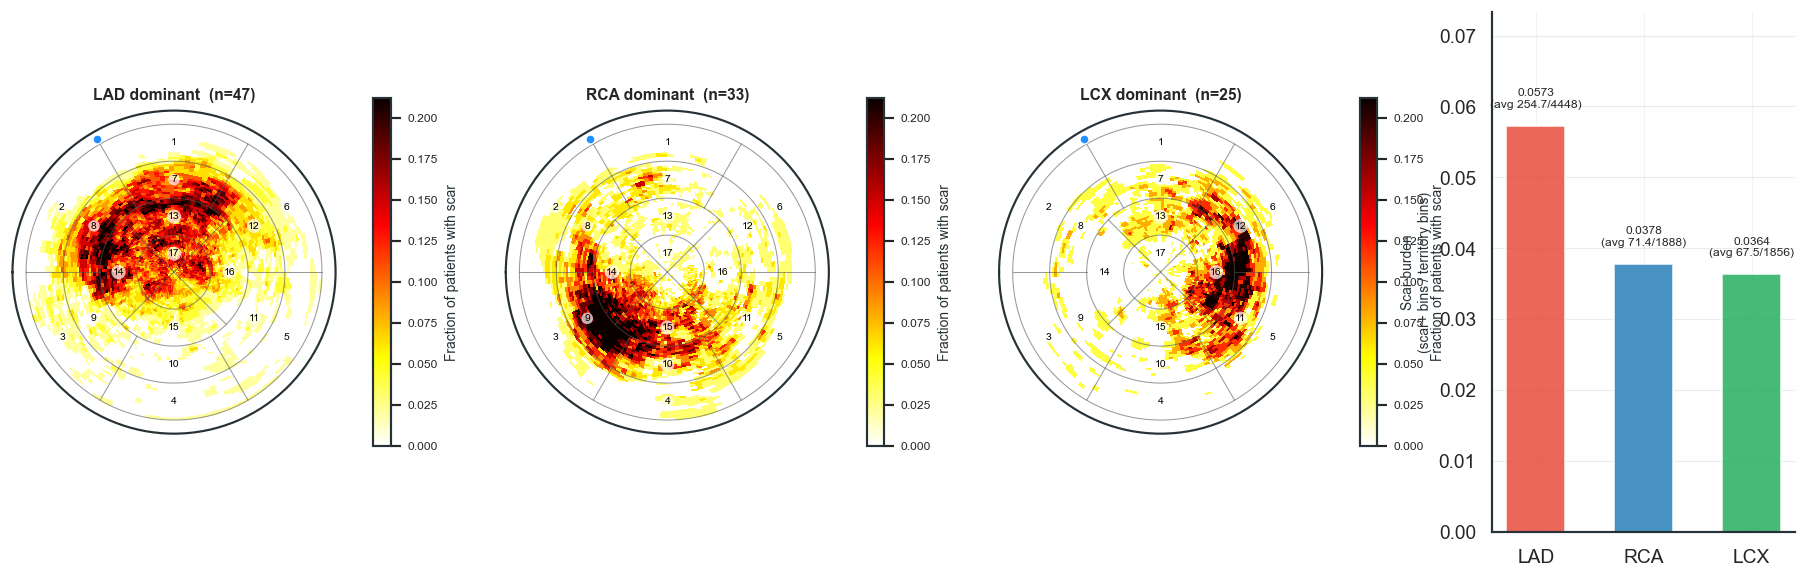

Saved: fig6_archetype_maps_territory_burden.png


In [49]:
# -- Fig 6 - Vertex archetype maps by dominant territory + mean scar burden
# Uses exact M04 logic: TERRITORY_GRID, region_burden_table, idxmax dominant
import matplotlib.gridspec as gridspec
from src import scar_characterization as scar_char

# -- constants (mirror M04 s3-code)
_F6_N_R, _F6_N_THETA = 64, 128
_F6_TERRITORY = {
    'LAD': [1, 2, 7, 8, 13, 14, 17],
    'RCA': [3, 4, 9, 10, 15],
    'LCX': [5, 6, 11, 12, 16],
}
_F6_TERR_COLORS = {'LAD': '#e74c3c', 'RCA': '#2980b9', 'LCX': '#27ae60'}
_F6_SCAR_THRESH = 0.02

def _f6_aha_grid(n_r=_F6_N_R, n_theta=_F6_N_THETA):
    labels = np.zeros((n_r, n_theta), dtype=np.int64)
    rc = (np.arange(n_r) + 0.5) / n_r
    tc = (np.arange(n_theta) + 0.5) / n_theta * 360.0
    for ri, radius in enumerate(rc):
        for ti, theta_deg in enumerate(tc):
            if radius < 0.25:
                labels[ri, ti] = 17
            elif radius < 0.50:
                if   45  <= theta_deg < 135: labels[ri, ti] = 13
                elif 135 <= theta_deg < 225: labels[ri, ti] = 16
                elif 225 <= theta_deg < 315: labels[ri, ti] = 15
                else:                        labels[ri, ti] = 14
            elif radius < 0.75:
                if   0   <= theta_deg < 60:  labels[ri, ti] = 8
                elif 60  <= theta_deg < 120: labels[ri, ti] = 7
                elif 120 <= theta_deg < 180: labels[ri, ti] = 12
                elif 180 <= theta_deg < 240: labels[ri, ti] = 11
                elif 240 <= theta_deg < 300: labels[ri, ti] = 10
                else:                        labels[ri, ti] = 9
            else:
                if   0   <= theta_deg < 60:  labels[ri, ti] = 2
                elif 60  <= theta_deg < 120: labels[ri, ti] = 1
                elif 120 <= theta_deg < 180: labels[ri, ti] = 6
                elif 180 <= theta_deg < 240: labels[ri, ti] = 5
                elif 240 <= theta_deg < 300: labels[ri, ti] = 4
                else:                        labels[ri, ti] = 3
    return labels

_F6_AHA_GRID       = _f6_aha_grid()
_F6_TERRITORY_GRID = np.full((_F6_N_R, _F6_N_THETA), '', dtype=object)
for _t, _segs in _F6_TERRITORY.items():
    for _s in _segs:
        _F6_TERRITORY_GRID[_F6_AHA_GRID == _s] = _t
_F6_TERR_NBINS = {t: int((_F6_TERRITORY_GRID == t).sum()) for t in _F6_TERRITORY}
print('Territory bin counts:', _F6_TERR_NBINS)

# -- bullseye helpers (mirror M04 s2-helpers)
_F6_AHA_SEG_LABELS = (
    (1, 90, 0.875), (2, 30, 0.875), (3, 330, 0.875),
    (4, 270, 0.875), (5, 210, 0.875), (6, 150, 0.875),
    (7, 90, 0.625), (8, 30, 0.625), (9, 330, 0.625),
    (10, 270, 0.625), (11, 210, 0.625), (12, 150, 0.625),
    (13, 90, 0.375), (14, 0, 0.375), (15, 270, 0.375),
    (16, 180, 0.375), (17, 90, 0.125),
)

def _f6_draw_grid(ax):
    t = np.linspace(0, 2 * np.pi, 361)
    for r in (0.25, 0.50, 0.75, 1.0):
        ax.plot(t, np.full_like(t, r), color='#555', lw=0.6, alpha=0.6)
    for deg in (0, 60, 120, 180, 240, 300):
        ax.plot([np.deg2rad(deg)] * 2, [0.5, 1.0], color='#555', lw=0.6, alpha=0.6)
    for deg in (45, 135, 225, 315):
        ax.plot([np.deg2rad(deg)] * 2, [0.0, 0.5], color='#555', lw=0.6, alpha=0.6)
    ax.set_theta_zero_location('W')
    ax.set_theta_direction(-1)
    ax.set_rticks([]); ax.set_xticks([])
    ax.scatter([np.deg2rad(60)], [1.04], s=26, color='dodgerblue',
               edgecolor='white', linewidth=0.7, zorder=10, clip_on=False)

def _f6_draw_bullseye(data, ax, title=None, cmap='hot_r', vmax=None, label_segs=False):
    arr = np.asarray(data, dtype=float)
    if vmax is None:
        vmax = max(float(np.nanmax(arr)), 1e-12)
    T, R = np.meshgrid(
        np.linspace(0, 2 * np.pi, arr.shape[1] + 1),
        np.linspace(0, 1.0,       arr.shape[0] + 1),
    )
    ax.set_theta_zero_location('W')
    ax.set_theta_direction(-1)
    mesh = ax.pcolormesh(T, R, arr, cmap=cmap, vmin=0, vmax=vmax, shading='flat')
    _f6_draw_grid(ax)
    if label_segs:
        for seg, deg, r in _F6_AHA_SEG_LABELS:
            ax.text(np.deg2rad(deg % 360), r, str(seg), fontsize=6,
                    ha='center', va='center', color='black',
                    bbox=dict(boxstyle='circle,pad=0.12', facecolor='white',
                              edgecolor='none', alpha=0.7))
    if title:
        ax.set_title(title, fontsize=9, pad=6)
    return mesh

# -- compute territory burden from pmaps (mirror M04 s4-code)
_f6_terr_raw = scar_char.region_burden_table(
    pmaps,
    _F6_TERRITORY_GRID,
    list(_F6_TERRITORY),
    normalize_by_region_size=True,
    include_raw=True,
)
_f6_terr_raw['dominant']   = _f6_terr_raw[list(_F6_TERRITORY)].idxmax(axis=1)
_f6_terr_raw['n_involved'] = (_f6_terr_raw[list(_F6_TERRITORY)] >= _F6_SCAR_THRESH).sum(axis=1).astype(int)
for _t in _F6_TERRITORY:
    _f6_terr_raw[f'{_t}_cz_bins'] = _f6_terr_raw[f'{_t}_raw'].astype(int)
print(f'Territory burden computed: {len(_f6_terr_raw)} patients')
print('Dominant:', _f6_terr_raw['dominant'].value_counts().to_dict())

# -- build per-territory mean polar maps
_f6_vmaps, _f6_ns = {}, {}
for _terr in _F6_TERRITORY:
    _keys = _f6_terr_raw.loc[_f6_terr_raw['dominant'] == _terr, 'key'].tolist()
    _keys = [k for k in _keys if k in pmaps]
    if _keys:
        _f6_vmaps[_terr] = np.stack([np.asarray(pmaps[k], dtype=float) for k in _keys]).mean(axis=0)
        _f6_ns[_terr] = len(_keys)

_f6_avail = [t for t in _F6_TERRITORY if t in _f6_vmaps]
if not _f6_avail:
    print('No archetype maps available.')
else:
    _f6_vmax = max(
        float(np.nanpercentile(_f6_vmaps[t][_f6_vmaps[t] > 0], 95))
        if (_f6_vmaps[t] > 0).any() else 0
        for t in _f6_avail
    )
    _f6_vmax = _f6_vmax if _f6_vmax > 0 else 1.0

    n_polar = len(_f6_avail)
    fig6 = plt.figure(figsize=(4.8 * n_polar + 4.0, 5.4))
    fig6.patch.set_facecolor('white')

    gs6 = gridspec.GridSpec(1, n_polar + 1, figure=fig6,
                            width_ratios=[1] * n_polar + [0.80],
                            wspace=0.32)
    for _col, _terr in enumerate(_f6_avail):
        ax6 = fig6.add_subplot(gs6[0, _col], projection='polar')
        _m6 = _f6_draw_bullseye(
            _f6_vmaps[_terr], ax6,
            title=f'{_terr} dominant  (n={_f6_ns[_terr]})',
            cmap='hot_r', vmax=_f6_vmax, label_segs=True,
        )
        cbar6 = ax6.figure.colorbar(_m6, ax=ax6, fraction=0.046, pad=0.10)
        cbar6.set_label('Fraction of patients with scar', fontsize=8)
        cbar6.ax.tick_params(labelsize=7)

    # -- mean territory scar burden bar chart (mirror M04 Fig 1 panel 1)
    ax6b = fig6.add_subplot(gs6[0, -1])
    _f6_means = [_f6_terr_raw[t].mean() for t in _F6_TERRITORY]
    _f6_cols  = [_F6_TERR_COLORS[t] for t in _F6_TERRITORY]
    _f6_ymax  = max(_f6_means) if _f6_means else 0
    bars6 = ax6b.bar(list(_F6_TERRITORY), _f6_means,
                     color=_f6_cols, alpha=0.85, edgecolor='white', width=0.55)
    for bar, t, mean in zip(bars6, _F6_TERRITORY, _f6_means):
        mean_bins = _f6_terr_raw[f'{t}_cz_bins'].mean()
        denom     = _F6_TERR_NBINS[t]
        ax6b.text(bar.get_x() + bar.get_width() / 2,
                  mean + max(_f6_ymax, 1e-9) * 0.04,
                  f'{mean:.4f}\n(avg {mean_bins:.1f}/{denom})',
                  ha='center', va='bottom', fontsize=7)
    ax6b.set_ylabel('Scar burden\n(scar+ bins / territory bins)', fontsize=8)
    ax6b.grid(axis='y', alpha=0.3)
    ax6b.set_ylim(0, max(_f6_ymax * 1.28, 0.01))
    ax6b.spines[['top', 'right']].set_visible(False)

    _f6_path = OUT / 'fig6_archetype_maps_territory_burden.png'
    fig6.savefig(_f6_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved: {_f6_path.name}')

## Fig 7 – Cohort gallery histogram (frontpage figure)

All 105 cases rendered as 3-D thumbnails (LV shell + Core Zone), arranged as a
histogram where each column is a CZ-burden bin and the height reflects case count.
The distribution is right-skewed (most patients have small scars).

Cases per bin: [48, 25, 12, 5, 4, 6, 0, 0, 3, 2]  (max=48)
Thumbnails rendered: 105


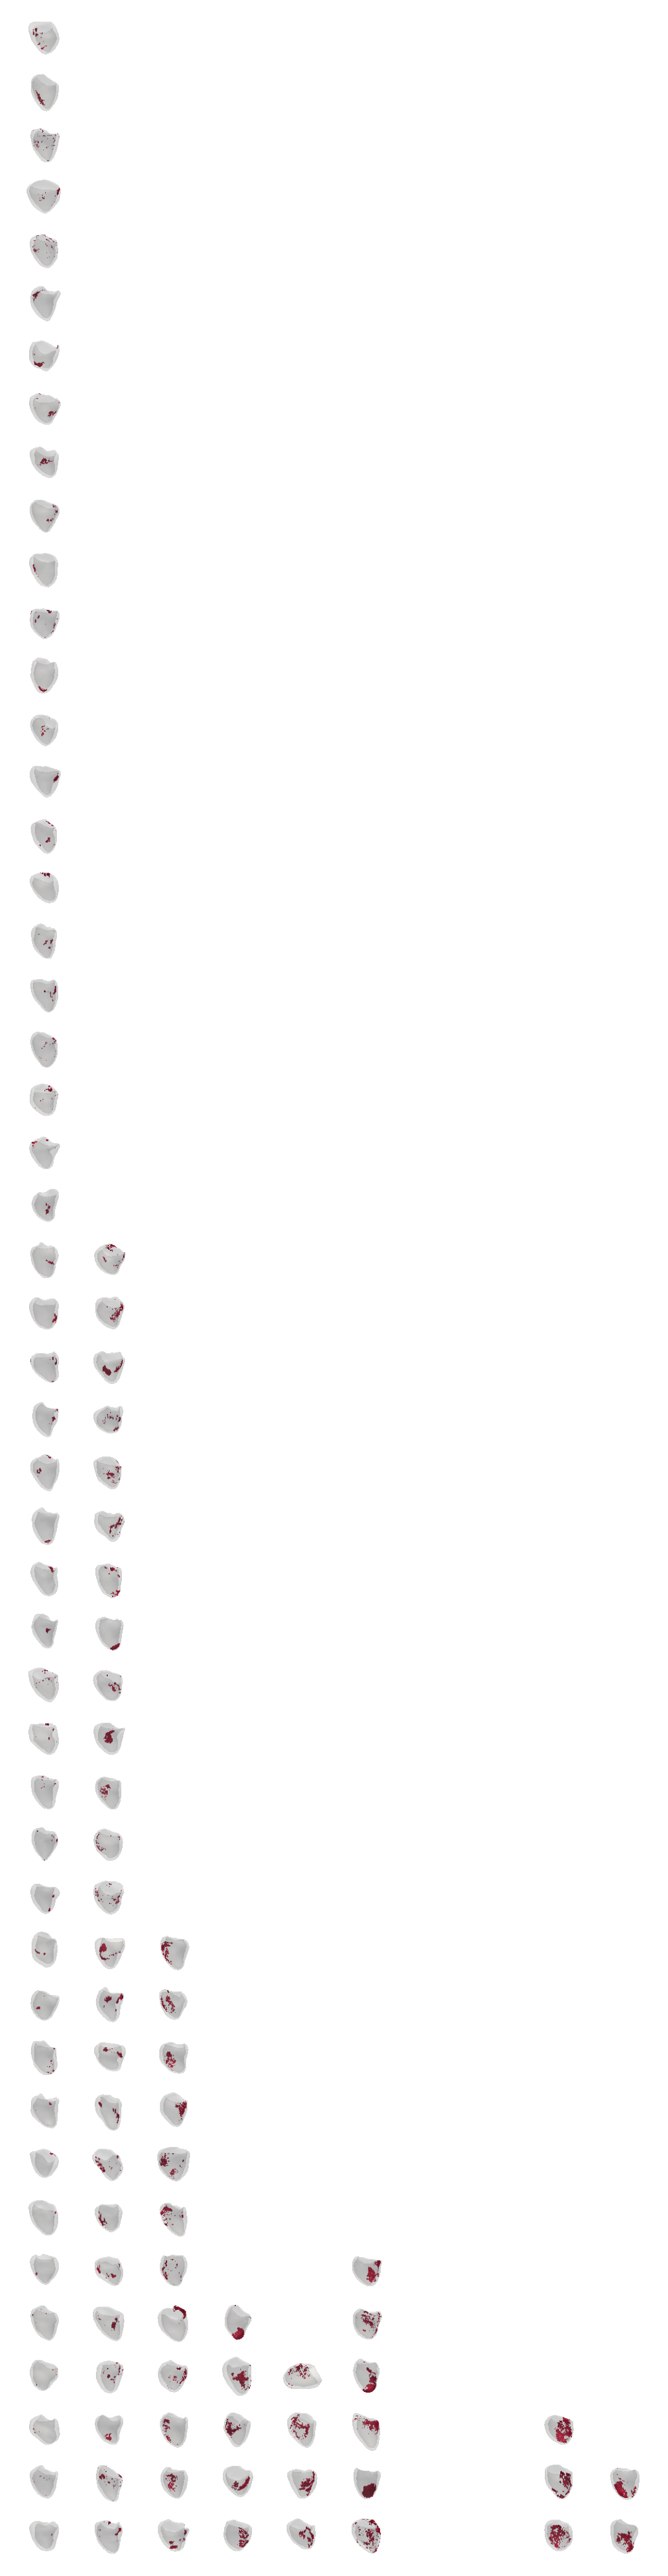

Saved: C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\lv-scar-segmentation\results\F01_figures\fig7_cohort_gallery_histogram.png  (105 cases)


In [4]:

# -- Fig 7: Cohort gallery histogram ------------------------------------------
from src.data_loading import scan as _f7_scan
from src.mesh_utils import best_shell as _f7_best_shell, get_cz_mesh as _f7_get_cz

_F7_N_BINS   = 10
_F7_THUMB_W  = 100
_F7_THUMB_H  = 85
_F7_DPI      = 200
_F7_C_SHELL  = '#cccccc'
_F7_C_CZ     = 'crimson'
_F7_OP_SHELL = 0.15
_F7_OP_CZ    = 0.95

_f7_all = all_cases if 'all_cases' in dir() else _f7_scan(HD_ROOT)
_f7_entries = []
for _c in _f7_all:
    _sh = _f7_best_shell(_c)
    _cz = _f7_get_cz(_c)
    if _sh is None or _cz is None:
        continue
    _f7_entries.append((_cz.area / 100.0, _c, _sh, _cz))

_f7_entries.sort(key=lambda x: x[0])
_f7_areas  = np.array([e[0] for e in _f7_entries])
_f7_edges  = np.linspace(_f7_areas.min(), _f7_areas.max(), _F7_N_BINS + 1)
_f7_labels = np.digitize(_f7_areas, _f7_edges[1:-1])

_f7_bins = [[] for _ in range(_F7_N_BINS)]
for _entry, _label in zip(_f7_entries, _f7_labels):
    _f7_bins[_label].append(_entry)

_f7_max_col = max(len(b) for b in _f7_bins)
print(f'Cases per bin: {[len(b) for b in _f7_bins]}  (max={_f7_max_col})')

_f7_thumbs = {}
for _bi, _bin in enumerate(_f7_bins):
    for _ri, (_area, _case, _sh, _cz) in enumerate(_bin):
        _pl = pv.Plotter(off_screen=True, window_size=(_F7_THUMB_W, _F7_THUMB_H))
        _pl.set_background('white')
        _pl.add_mesh(_sh, color=_F7_C_SHELL, opacity=_F7_OP_SHELL,
                     smooth_shading=True, show_scalar_bar=False)
        _pl.add_mesh(_cz, color=_F7_C_CZ, opacity=_F7_OP_CZ,
                     smooth_shading=True, show_scalar_bar=False)
        _pl.view_isometric()
        _f7_thumbs[(_bi, _ri)] = _pl.screenshot(None, return_img=True)
        _pl.close()

print(f'Thumbnails rendered: {len(_f7_thumbs)}')

import matplotlib.gridspec as _f7_gs_mod

_fig7_w = _F7_N_BINS * _F7_THUMB_W / _F7_DPI + 0.2
_fig7_h = _f7_max_col * _F7_THUMB_H / _F7_DPI + 0.2

fig7 = plt.figure(figsize=(_fig7_w, _fig7_h), dpi=_F7_DPI)
fig7.patch.set_facecolor('white')

gs7 = _f7_gs_mod.GridSpec(
    _f7_max_col, _F7_N_BINS,
    figure=fig7,
    hspace=0.0, wspace=0.0,
    left=0.0, right=1.0,
    bottom=0.0, top=1.0,
)

for _bi in range(_F7_N_BINS):
    _n = len(_f7_bins[_bi])
    for _ri in range(_f7_max_col):
        _grid_row = _f7_max_col - 1 - _ri
        _ax = fig7.add_subplot(gs7[_grid_row, _bi])
        _ax.axis('off')
        if _ri < _n:
            _ax.imshow(_f7_thumbs[(_bi, _ri)], aspect='auto')
        else:
            _ax.set_facecolor('none')

_f7_path = OUT / 'fig7_cohort_gallery_histogram.png'
fig7.savefig(_f7_path, dpi=_F7_DPI, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {_f7_path}  ({len(_f7_thumbs)} cases)')
